In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm.auto import tqdm
from scipy.stats import chi2
from scipy.linalg import sqrtm
import cvxpy as cp
import warnings
warnings.filterwarnings('ignore')

d:\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.DataFrame([])
data_list = ['stock_monthly1991-2000', 'stock_monthly2001-2010', 'stock_monthly2011-2020']
for data_name in data_list:
    data = pd.concat([data, pd.read_pickle(data_name+'.pickle')]).reset_index(drop=True)
data['obs'] = data.groupby(['permno'])['month'].transform('nunique')
data = data[data['obs'] >= 300].reset_index(drop=True)
data = data.pivot(index='month', columns='permno', values='monthly_ret')
volatility = data.std()
low_vol_stocks = volatility.nsmallest(500).index
data = data[low_vol_stocks]

In [3]:
def Equal_Weighted(returns_array):
    n_stocks = returns_array.shape[1]
    weight = 1.0 / n_stocks
    weights_col_vector = np.full((n_stocks, 1), weight)
    return weights_col_vector

def DRMV(returns, alpha_bar = 0.10 / 12, delta = 0.1, p = 2):
    n, d = returns.shape
    mu = np.mean(returns, axis=0)
    Sigma = returns.T @ returns / n
    V = Sigma - np.outer(mu, mu)
    
    def objective(phi):
        var_term = np.sqrt(phi.T @ V @ phi)
        reg_term = np.sqrt(delta) * np.linalg.norm(phi, ord=p)
        return float(var_term + reg_term)
    
    cons = [
        {'type': 'eq',   'fun': lambda phi: np.sum(phi) - 1.0},
        {'type': 'ineq', 'fun': lambda phi: mu @ phi - (alpha_bar + np.sqrt(delta) * np.linalg.norm(phi, ord=p))}
    ]
    
    res = minimize(objective, x0=np.ones(d)/d, method='SLSQP', constraints=cons,
        options={'disp': False, 'maxiter': 500, 'ftol': 1e-9},
        tol=1e-9
    )
    
    weights = res.x.reshape(-1, 1)
    weights = weights / np.sum(weights)
    return weights

In [4]:
# BACKTEST_START = "2001-01" 
# BACKTEST_END   = "2016-12"
# DATE = [d for d in data[(data.index >= BACKTEST_START) & (data.index <= BACKTEST_END)].index]
# port_ret = {'Single_Period_Markowitz': [], 'Equal_Weighted': [], 'DRMV': []} | {f'DRMV_\delta=1e-{i}':[] for i in range(1, 8)}
# for i, date in enumerate(DATE):
#     print('\r', date, end = '')
#     data_cut = data.iloc[i:i+120+1]
#     data_cut = data_cut.dropna(axis=1).sample(20, axis=1, random_state=42).values
#     train_data = data_cut[:-1, :]
#     test_data  = data_cut[-1:, :]
#     weight_ew = Equal_Weighted(train_data)
#     port_ret['Equal_Weighted'].append(test_data @ weight_ew)
#     weight_spm = DRMV(train_data, 0.1/12, 0)
#     port_ret['Single_Period_Markowitz'].append(test_data @ weight_spm)
#     for i in range(1, 8):
#         weight_drvm = DRMV(train_data, 0.1/12, 10**(-i))
#         port_ret[f'DRMV_\delta=1e-{i}'].append(test_data @ weight_drvm)

In [5]:
BACKTEST_START = "2001-01" 
BACKTEST_END   = "2016-12"
DATE = [d for d in data[(data.index >= BACKTEST_START) & (data.index <= BACKTEST_END)].index]
strategies = ['Single_Period_Markowitz', 'Equal_Weighted'] + [f'DRMV_\delta=1e-{i}' for i in range(1, 8)]
port_ret = {s: [] for s in strategies}

for i, date in enumerate(DATE):
    print('\r', date, end = '')
    data_pool = data.iloc[i : i + 120 + 1].dropna(axis=1)
    temp_sum = {s: 0.0 for s in strategies}
    num_samples = 10
    
    for s in range(num_samples):
        data_cut = data_pool.sample(50, axis=1, random_state=s).values
        train_data = data_cut[:-1, :]
        test_data  = data_cut[-1:, :]
        
        w_ew = Equal_Weighted(train_data)
        temp_sum['Equal_Weighted'] += (test_data @ w_ew)[0]
        
        w_spm = DRMV(train_data, 0.1/12, 0)
        temp_sum['Single_Period_Markowitz'] += (test_data @ w_spm)[0]
        
        for j in range(1, 8):
            key = f'DRMV_\delta=1e-{j}'
            w_drvm = DRMV(train_data, 0.1/12, 10**(-j))
            temp_sum[key] += (test_data @ w_drvm)[0]
            
    for s in strategies:
        port_ret[s].append(temp_sum[s] / num_samples)

 2016-12

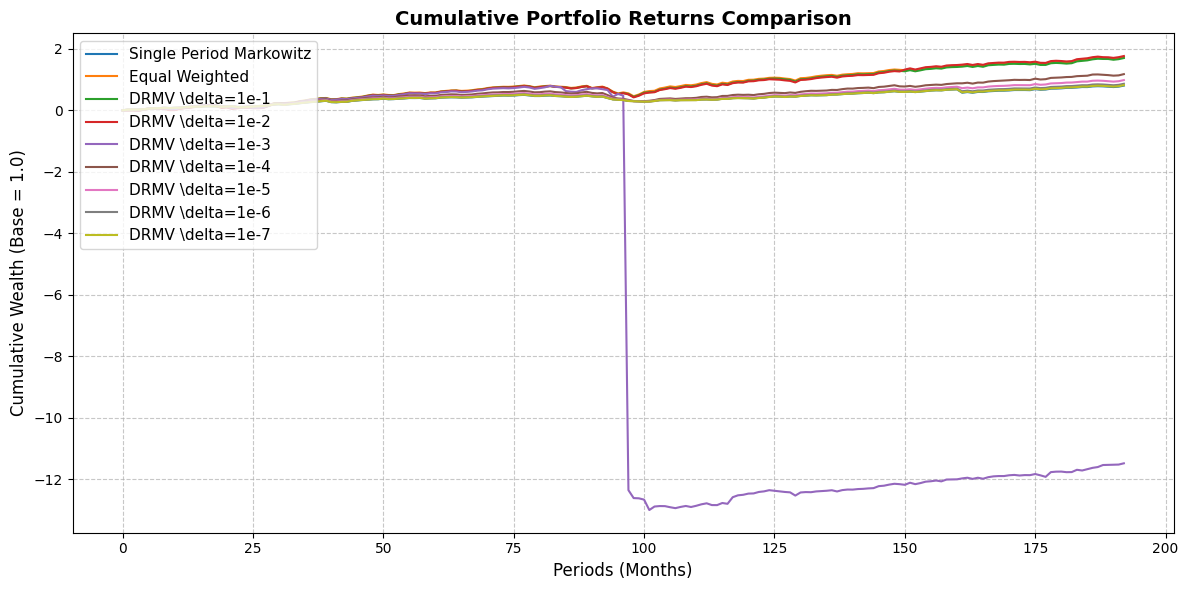

In [6]:
plt.figure(figsize=(12, 6), dpi=100)
for strategy_name, returns_list in port_ret.items():
    # if strategy_name in ['DRMV_\delta=1e-1', 'DRMV_\delta=1e-3']:
    #     continue
    returns_array = np.array(returns_list).flatten()
    cumulative_returns = np.cumsum(returns_array)
    cumulative_returns = np.insert(cumulative_returns, 0, 0)
    plt.plot(cumulative_returns, label=strategy_name.replace('_', ' '), linewidth=1.5)

plt.title('Cumulative Portfolio Returns Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Periods (Months)', fontsize=12)
plt.ylabel('Cumulative Wealth (Base = 1.0)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
df_ret = pd.DataFrame({
    k: np.ravel(v) for k, v in port_ret.items() if len(v) > 0
})

df_ret.index = pd.to_datetime(DATE)

annual_rf = 0.02
months_in_year = 12

stats = pd.DataFrame(index=df_ret.columns)

# 年化算术平均收益
stats['Annualized Mean'] = df_ret.mean() * months_in_year

# 年化标准差 (风险)
stats['Annualized Volatility'] = df_ret.std() * np.sqrt(months_in_year)

# 年化夏普比率
stats['Sharpe Ratio'] = (stats['Annualized Mean'] - annual_rf) / stats['Annualized Volatility']

annual_returns_table = df_ret.groupby(df_ret.index.year).apply(lambda x: (x).sum())

# --- 4. 格式化输出 ---
print("----- 策略表现统计 (年化) -----")
print(stats.round(4))

print("\n----- 分年回报率 (年度累积) -----")
# 转置后行是方法，列是年份，更符合论文或报告格式
print(annual_returns_table.T.round(4))



----- 策略表现统计 (年化) -----
                         Annualized Mean  Annualized Volatility  Sharpe Ratio
Single_Period_Markowitz           0.0503                 0.0552        0.5489
Equal_Weighted                    0.1086                 0.0972        0.9110
DRMV_\delta=1e-1                  0.1063                 0.0981        0.8795
DRMV_\delta=1e-2                  0.1104                 0.1014        0.8912
DRMV_\delta=1e-3                 -0.7176                 3.2144       -0.2295
DRMV_\delta=1e-4                  0.0736                 0.0662        0.8095
DRMV_\delta=1e-5                  0.0614                 0.0565        0.7339
DRMV_\delta=1e-6                  0.0540                 0.0550        0.6184
DRMV_\delta=1e-7                  0.0512                 0.0551        0.5659

----- 分年回报率 (年度累积) -----
                           2001    2002    2003    2004    2005    2006  \
Single_Period_Markowitz  0.1018  0.0098  0.1549  0.0910  0.0327  0.0826   
Equal_Weighted      